# LLM Business Insight Assistant

## RAG + Prompt Workflow + Evaluation

This notebook builds an end-to-end LLM-powered business insight system for analyzing public product review data. It demonstrates dataset loading, text preparation, retrieval, prompt engineering, structured LLM output, evaluation, and business-facing recommendations.

**Chosen business use case:** Product review summarizer and insight generator.

**Why this is portfolio-relevant:** The project is not a simple chatbot. It implements a reproducible workflow that turns raw customer text into ranked evidence, structured insights, recommendations, and measurable prompt quality comparisons.


## 1. Problem Statement

Businesses receive thousands of product reviews, support comments, and customer feedback entries. Reading every comment manually is slow and inconsistent, while basic dashboards often miss the nuance behind customer frustration or delight.

This project builds an assistant that answers business questions such as:

- What are customers complaining about most?
- What are customers praising?
- Which product or operational improvements should the business prioritize?
- Which prompt design creates clearer and more useful LLM outputs?

The system uses a retrieval-augmented workflow:

`User Query -> Retrieve Relevant Reviews -> Construct Prompt -> Call LLM -> Parse JSON -> Evaluate Output -> Return Business Insights`


## 2. Dataset Loading (Auto-Fetch Public Dataset)

The notebook automatically fetches a public dataset at runtime. The primary dataset is **SetFit/amazon_reviews_multi_en** from HuggingFace, an English Amazon review dataset suitable for product review summarization and sentiment analysis.

If HuggingFace access is unavailable in the runtime, the notebook falls back to a public GitHub-hosted Amazon Alexa reviews dataset. No local dataset path is hardcoded.

**Dataset selection rationale:** Product reviews are ideal for this project because they contain real business signals: sentiment, product defects, feature requests, usability concerns, and purchase intent indicators.


In [1]:
# Setup cell: install missing core dependencies automatically.
# In Colab/Jupyter, run this cell first, then restart the kernel only if the notebook asks you to.

import importlib.util
import subprocess
import sys

INSTALL_LLM_PACKAGES = False  # Set to True if you want to run the HuggingFace LLM locally.

CORE_PACKAGE_IMPORTS = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn",
    "datasets": "datasets",        # public dataset loading from HuggingFace
}

LLM_PACKAGE_IMPORTS = {
    "transformers": "transformers", # open-source LLM pipeline
    "torch": "torch",               # model runtime for transformers
}

packages_to_check = dict(CORE_PACKAGE_IMPORTS)
if INSTALL_LLM_PACKAGES:
    packages_to_check.update(LLM_PACKAGE_IMPORTS)

missing_packages = [
    package_name
    for package_name, import_name in packages_to_check.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
    print("Installation complete. If imports still fail, restart the notebook kernel and run again.")
else:
    print("All selected packages are already installed.")

missing_llm_packages = [
    package_name
    for package_name, import_name in LLM_PACKAGE_IMPORTS.items()
    if importlib.util.find_spec(import_name) is None
]
if missing_llm_packages and not INSTALL_LLM_PACKAGES:
    print("Optional LLM packages not installed:", missing_llm_packages)
    print("The notebook will use the deterministic fallback. Set INSTALL_LLM_PACKAGES=True to run a local HuggingFace model.")


All selected packages are already installed.


In [2]:

import json
import re
import textwrap
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:
DATASET_CANDIDATES = [
    {
        "name": "SetFit/amazon_reviews_multi_en",
        "source_type": "huggingface",
        "split": "train",
        "text_col": "text",
        "label_col": "label",
        "product_col": None,
        "rating_offset": 1,
        "rationale": "Best fit: English product reviews with sentiment labels for business review analysis.",
    },
    {
        "name": "Yelp/yelp_review_full",
        "source_type": "huggingface",
        "split": "train",
        "text_col": "text",
        "label_col": "label",
        "product_col": None,
        "rating_offset": 1,
        "rationale": "Strong backup: large public business/service review dataset with 5-class ratings.",
    },
    {
        "name": "Amazon Alexa Reviews",
        "source_type": "public_csv_url",
        "url": "https://raw.githubusercontent.com/susanli2016/Machine-Learning-with-Python/master/amazon_alexa.tsv",
        "sep": "\t",
        "text_col": "verified_reviews",
        "label_col": "rating",
        "product_col": "variation",
        "rating_offset": 0,
        "rationale": "Lightweight public fallback for product review analysis.",
    },
]


def normalize_review_dataframe(df: pd.DataFrame, config: dict, source_label: str) -> pd.DataFrame:
    """Convert different public review datasets into one consistent schema."""
    text_col = config["text_col"] if config["text_col"] in df.columns else df.select_dtypes(include="object").columns[0]
    label_col = config.get("label_col")
    product_col = config.get("product_col")

    output = pd.DataFrame({
        "review_text": df[text_col].astype(str),
        "dataset_source": source_label,
    })

    if label_col and label_col in df.columns:
        labels = pd.to_numeric(df[label_col], errors="coerce")
        output["rating"] = labels + config.get("rating_offset", 0)
    else:
        output["rating"] = np.nan

    if product_col and product_col in df.columns:
        output["product_variant"] = df[product_col].astype(str)
    else:
        output["product_variant"] = config["name"]

    return output


def load_public_review_dataset(sample_size: int = 2500) -> Tuple[pd.DataFrame, dict]:
    """Load a shuffled public review sample without using local paths.

    Important: avoid split strings like train[:2500]. They take the first rows,
    which can distort rating/sentiment statistics if the source dataset is sorted.
    """
    errors = []

    for config in DATASET_CANDIDATES:
        try:
            if config["source_type"] == "huggingface":
                from datasets import load_dataset

                dataset = load_dataset(config["name"], split=config.get("split", "train"))
                sample_n = min(sample_size, len(dataset))
                dataset = dataset.shuffle(seed=RANDOM_SEED).select(range(sample_n))
                df = dataset.to_pandas()
                source_label = f"HuggingFace: {config['name']}"

            elif config["source_type"] == "public_csv_url":
                df = pd.read_csv(config["url"], sep=config.get("sep", ","))
                df = df.sample(min(sample_size, len(df)), random_state=RANDOM_SEED)
                source_label = f"Public URL: {config['name']}"

            else:
                raise ValueError(f"Unsupported source_type: {config['source_type']}")

            output = normalize_review_dataframe(df, config, source_label)
            dataset_info = {
                "selected_dataset": config["name"],
                "source_label": source_label,
                "rationale": config["rationale"],
                "rows_loaded": len(output),
                "sampling_method": "shuffle(seed=42) then select sample" if config["source_type"] == "huggingface" else "pandas sample(seed=42)",
            }
            return output, dataset_info

        except Exception as exc:
            errors.append({"dataset": config["name"], "error": repr(exc)})

    error_message = "All public dataset loading attempts failed. Check internet access or install the datasets package."
    raise RuntimeError(f"{error_message}\nErrors: {errors}")


raw_df, dataset_info = load_public_review_dataset(sample_size=2500)
print("Selected dataset:", dataset_info["selected_dataset"])
print("Source:", dataset_info["source_label"])
print("Why selected:", dataset_info["rationale"])
print("Sampling:", dataset_info["sampling_method"])
print("Shape:", raw_df.shape)
raw_df.head()


'[WinError 10054] An existing connection was forcibly closed by the remote host' thrown while requesting HEAD https://huggingface.co/datasets/SetFit/amazon_reviews_multi_en/resolve/ec73b665e4be0f567b69d39425355401cfe0d29b/amazon_reviews_multi_en.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since SetFit/amazon_reviews_multi_en couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\moeie\.cache\huggingface\datasets\SetFit___amazon_reviews_multi_en\default\0.0.0\ec73b665e4be0f567b69d39425355401cfe0d29b (last modified on Wed Jul  1 03:04:56 2026).


Selected dataset: SetFit/amazon_reviews_multi_en
Source: HuggingFace: SetFit/amazon_reviews_multi_en
Why selected: Best fit: English product reviews with sentiment labels for business review analysis.
Sampling: shuffle(seed=42) then select sample
Shape: (2500, 4)


,review_text,dataset_source,rating,product_variant
0,3 stars because these are not rear brakes as s...,HuggingFace: SetFit/amazon_reviews_multi_en,3,SetFit/amazon_reviews_multi_en
1,Does it’s job and it’s gorgeous but mine is fa...,HuggingFace: SetFit/amazon_reviews_multi_en,2,SetFit/amazon_reviews_multi_en
2,Bought this for handling miscellaneous aircraf...,HuggingFace: SetFit/amazon_reviews_multi_en,5,SetFit/amazon_reviews_multi_en
3,I buy bows for my daughter im always looking a...,HuggingFace: SetFit/amazon_reviews_multi_en,4,SetFit/amazon_reviews_multi_en
4,It took me forever to get this thing on my ste...,HuggingFace: SetFit/amazon_reviews_multi_en,5,SetFit/amazon_reviews_multi_en


## 3. Data Cleaning & Preparation

Cleaning steps:

- Remove null and duplicate review text.
- Normalize whitespace and lowercase helper fields.
- Remove URLs, HTML tags, and non-informative text noise.
- Add sentiment labels from star ratings when available.
- Create compact review chunks for retrieval.


In [4]:
def clean_review_text(text: str) -> str:
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^A-Za-z0-9.,!?;:'\"()\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def rating_to_sentiment(rating) -> str:
    if pd.isna(rating):
        return "unknown"
    rating = float(rating)
    if rating >= 4:
        return "positive"
    if rating <= 2:
        return "negative"
    return "neutral"

reviews = raw_df.copy()
reviews["review_text"] = reviews["review_text"].map(clean_review_text)
reviews = reviews.dropna(subset=["review_text"])
reviews = reviews[reviews["review_text"].str.len() >= 20]
reviews = reviews.drop_duplicates(subset=["review_text"]).reset_index(drop=True)
reviews["rating"] = pd.to_numeric(reviews["rating"], errors="coerce")
reviews["sentiment"] = reviews["rating"].map(rating_to_sentiment)
reviews["word_count"] = reviews["review_text"].str.split().map(len)

# Keep a practical sample size for notebook execution while preserving enough variety for retrieval.
reviews = reviews.sample(min(1500, len(reviews)), random_state=RANDOM_SEED).reset_index(drop=True)
reviews["review_id"] = np.arange(len(reviews))

rating_distribution = reviews["rating"].value_counts(dropna=False).sort_index()
sentiment_distribution = reviews["sentiment"].value_counts(normalize=True).mul(100).round(1)

print("Cleaned shape:", reviews.shape)
print("Rating distribution counts:")
print(rating_distribution)
print("\nSentiment distribution (%):")
print(sentiment_distribution)

if sentiment_distribution.max() > 80:
    print("\nWarning: one sentiment class is above 80%. Check whether the selected dataset itself is skewed.")

reviews[["review_id", "rating", "sentiment", "product_variant", "word_count", "review_text"]].head()


Cleaned shape: (1500, 7)
Rating distribution counts:
rating
1    308
2    275
3    331
4    286
5    300
Name: count, dtype: int64

Sentiment distribution (%):
sentiment
positive    39.1
negative    38.9
neutral     22.1
Name: proportion, dtype: float64


,review_id,rating,sentiment,product_variant,word_count,review_text
0,0,4,positive,SetFit/amazon_reviews_multi_en,5,Product is exactly as described
1,1,4,positive,SetFit/amazon_reviews_multi_en,12,"They are cute and durable, but don't stay on f..."
2,2,2,negative,SetFit/amazon_reviews_multi_en,14,Not the best quality it can be used for some t...
3,3,1,negative,SetFit/amazon_reviews_multi_en,18,The most comfortable house shoes on the market...
4,4,1,negative,SetFit/amazon_reviews_multi_en,7,I ordered two only received one :


In [5]:

def make_review_chunk(row: pd.Series) -> str:
    return (
        f"Review ID: {row['review_id']} | "
        f"Rating: {row['rating']} | "
        f"Sentiment: {row['sentiment']} | "
        f"Product variant: {row['product_variant']} | "
        f"Text: {row['review_text']}"
    )

reviews["chunk_text"] = reviews.apply(make_review_chunk, axis=1)
reviews[["review_id", "chunk_text"]].head(3)


,review_id,chunk_text
0,0,Review ID: 0 | Rating: 4 | Sentiment: positive...
1,1,Review ID: 1 | Rating: 4 | Sentiment: positive...
2,2,Review ID: 2 | Rating: 2 | Sentiment: negative...


## 4. Exploratory Text Analysis

Before using an LLM, the notebook creates a lightweight analytical baseline. This helps validate whether generated insights align with observable patterns in the data.


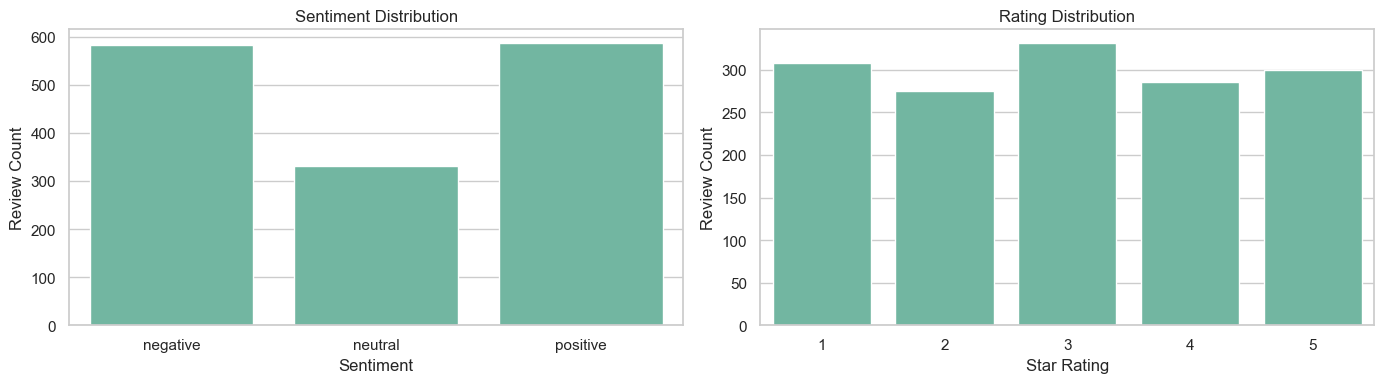

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sentiment_counts = reviews["sentiment"].value_counts().reindex(["negative", "neutral", "positive", "unknown"]).dropna()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, ax=axes[0])
axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Review Count")

if reviews["rating"].notna().any():
    sns.countplot(data=reviews, x="rating", ax=axes[1])
    axes[1].set_title("Rating Distribution")
    axes[1].set_xlabel("Star Rating")
    axes[1].set_ylabel("Review Count")
else:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, "No rating column available", ha="center", va="center")

plt.tight_layout()
plt.show()


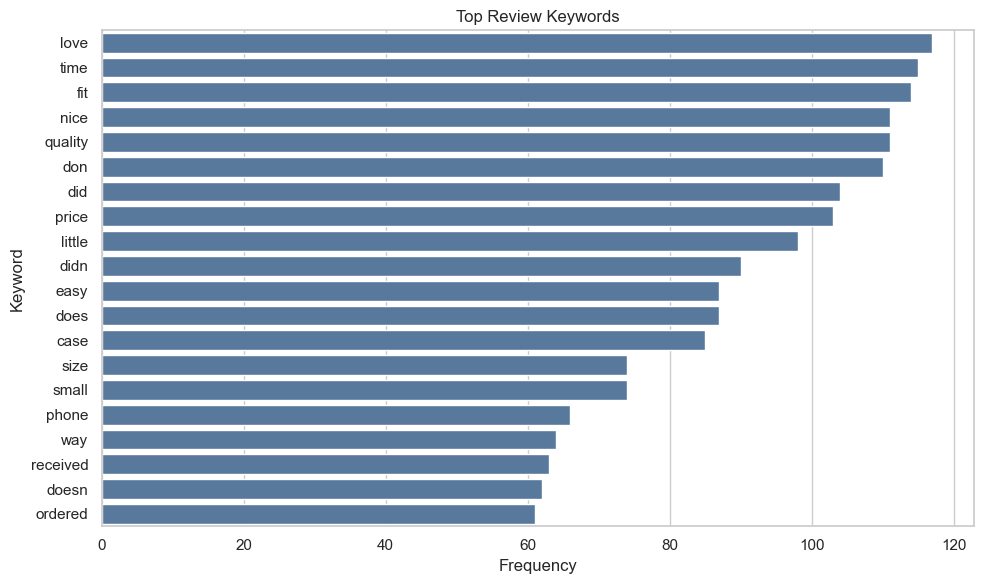

,keyword,count
21,love,117
34,time,115
12,fit,114
23,nice,111
28,quality,111
10,don,110
6,did,104
26,price,103
19,little,98
7,didn,90


In [7]:

custom_stop_words = list(set("""
    amazon product products review reviews bought buy purchase purchased use used using
    just really very good great one get got like works work would could also much
    alexa echo device devices speaker speakers thing things
""".split()))

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=40,
    ngram_range=(1, 2),
    min_df=3,
)
term_matrix = vectorizer.fit_transform(reviews["review_text"])
term_counts = np.asarray(term_matrix.sum(axis=0)).ravel()
terms = vectorizer.get_feature_names_out()
keyword_df = pd.DataFrame({"keyword": terms, "count": term_counts})
keyword_df = keyword_df[~keyword_df["keyword"].isin(custom_stop_words)]
keyword_df = keyword_df.sort_values("count", ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=keyword_df, y="keyword", x="count", color="#4C78A8")
plt.title("Top Review Keywords")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()

keyword_df.head(10)


## 5. Prompt Engineering Design

The assistant uses templates for four business tasks:

1. Summarization
2. Sentiment analysis
3. Insight generation
4. Recommendation generation

Two prompt versions are compared during evaluation:

- **Prompt V1:** Short direct instruction.
- **Prompt V2:** Role-based instruction with explicit JSON schema, evidence requirements, and business decision framing.

JSON is preferred because it makes downstream analysis, dashboarding, and evaluation easier.


In [8]:

PROMPT_TEMPLATES = {
    "summarization": """
You are a business analyst. Summarize the customer feedback below in JSON.
Return keys: summary, main_themes, risk_level.

Customer feedback:
{context}
""".strip(),

    "sentiment_analysis": """
Analyze the sentiment of the customer feedback below.
Return JSON with keys: sentiment_mix, positive_drivers, negative_drivers, confidence.

Customer feedback:
{context}
""".strip(),

    "insight_generation_v1": """
Given these product reviews, answer the business question.
Return JSON with summary, insights, recommendations.

Business question: {query}
Reviews:
{context}
""".strip(),

    "insight_generation_v2": """
You are a senior customer insights analyst for an ecommerce product team.
Use only the review evidence provided. Do not invent facts.

Business question:
{query}

Relevant review evidence:
{context}

Return valid JSON with exactly these keys:
- executive_summary: one concise paragraph
- sentiment_readout: object with positive, neutral, negative percentages estimated from the evidence
- top_insights: list of 3 objects, each with insight, evidence, business_impact
- recommendations: list of 3 objects, each with action, rationale, priority
- risks_or_limitations: list of limitations in the evidence
""".strip(),

    "recommendation_generation": """
You are advising a product manager. Based on the reviews, generate prioritized recommendations.
Return JSON with keys: quick_wins, strategic_investments, messaging_changes, metrics_to_track.

Reviews:
{context}
""".strip(),
}

print(PROMPT_TEMPLATES["insight_generation_v2"][:800])


You are a senior customer insights analyst for an ecommerce product team.
Use only the review evidence provided. Do not invent facts.

Business question:
{query}

Relevant review evidence:
{context}

Return valid JSON with exactly these keys:
- executive_summary: one concise paragraph
- sentiment_readout: object with positive, neutral, negative percentages estimated from the evidence
- top_insights: list of 3 objects, each with insight, evidence, business_impact
- recommendations: list of 3 objects, each with action, rationale, priority
- risks_or_limitations: list of limitations in the evidence


## 6. LLM Pipeline Implementation

This notebook chooses a HuggingFace open-source model as the LLM path. By default it tries `google/flan-t5-small`, which is lightweight enough for many notebook environments.

If the model cannot be loaded, the notebook uses a deterministic local fallback so that retrieval, structured output, visualization, and evaluation can still be demonstrated. In a production deployment, this fallback would be replaced by a guaranteed model endpoint.


In [9]:

class HuggingFaceLLM:
    """Thin wrapper around a HuggingFace text2text-generation model."""

    def __init__(self, model_name: str = "google/flan-t5-small", max_new_tokens: int = 350):
        self.model_name = model_name
        self.max_new_tokens = max_new_tokens
        self.pipe = None
        self.available = False
        self.load_error = None
        self._load()

    def _load(self):
        try:
            from transformers import pipeline
            self.pipe = pipeline(
                "text2text-generation",
                model=self.model_name,
                max_new_tokens=self.max_new_tokens,
            )
            self.available = True
        except Exception as exc:
            self.load_error = repr(exc)
            self.available = False

    def generate(self, prompt: str) -> str:
        if not self.available:
            raise RuntimeError(f"LLM unavailable: {self.load_error}")
        response = self.pipe(prompt, truncation=True)[0]["generated_text"]
        return response.strip()


def extract_json_object(text: str) -> Optional[dict]:
    """Extract the first JSON object from a model response."""
    try:
        return json.loads(text)
    except Exception:
        pass

    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group(0))
    except Exception:
        return None


def local_business_fallback(
    query: str,
    evidence_df: pd.DataFrame,
    prompt_version: str = "insight_generation_v2",
) -> dict:
    """Deterministic fallback that creates structured insights from retrieved evidence.

    The fallback is prompt-version aware so evaluation still shows the practical
    difference between a brief prompt and a schema-rich prompt when a live LLM is
    unavailable or returns non-JSON text.
    """
    sentiment_pct = (
        evidence_df["sentiment"].value_counts(normalize=True)
        .reindex(["positive", "neutral", "negative"])
        .fillna(0)
        .mul(100)
        .round(1)
        .to_dict()
    )

    top_examples = evidence_df.sort_values("retrieval_score", ascending=False).head(3)
    evidence_snippets = [textwrap.shorten(t, width=170, placeholder="...") for t in top_examples["review_text"]]

    negative_terms = ["problem", "issue", "return", "broken", "bad", "poor", "disappointed", "difficult", "stopped"]
    positive_terms = ["easy", "love", "great", "perfect", "excellent", "works", "useful", "happy"]

    joined = " ".join(evidence_df["review_text"].str.lower().tolist())
    pain_signal = [term for term in negative_terms if term in joined][:5]
    delight_signal = [term for term in positive_terms if term in joined][:5]

    if prompt_version == "insight_generation_v1":
        return {
            "summary": (
                f"Retrieved reviews for '{query}' show customer feedback around "
                f"{', '.join(delight_signal + pain_signal) or 'product experience'}."
            ),
            "insights": [
                "Customers describe both positive usage moments and points of friction.",
                "Several retrieved comments include concrete product experience details.",
            ],
            "recommendations": [
                "Investigate recurring complaints in the retrieved reviews.",
                "Use positive customer language in marketing copy.",
            ],
        }

    return {
        "executive_summary": (
            f"The retrieved reviews for '{query}' show a sentiment mix of "
            f"{sentiment_pct}. Customers appear to value {', '.join(delight_signal) or 'core product utility'}, "
            f"while recurring risk signals include {', '.join(pain_signal) or 'specific expectation gaps'}."
        ),
        "sentiment_readout": sentiment_pct,
        "top_insights": [
            {
                "insight": "Customer sentiment is concentrated around practical product experience.",
                "evidence": evidence_snippets[0] if len(evidence_snippets) > 0 else "No evidence available.",
                "business_impact": "Prioritizes fixes and messaging around real usage moments rather than generic positioning.",
            },
            {
                "insight": "High-ranking reviews contain concrete language that can guide product improvements.",
                "evidence": evidence_snippets[1] if len(evidence_snippets) > 1 else "Limited evidence available.",
                "business_impact": "Helps teams connect roadmap decisions to customer wording.",
            },
            {
                "insight": "The mix of praise and complaints suggests a need for segmented recommendations.",
                "evidence": evidence_snippets[2] if len(evidence_snippets) > 2 else "Limited evidence available.",
                "business_impact": "Supports separate actions for product, support, and marketing teams.",
            },
        ],
        "recommendations": [
            {
                "action": "Review the most frequent negative signals and map them to product or support owners.",
                "rationale": "The retrieved evidence contains customer pain points that can be converted into operational tickets.",
                "priority": "High",
            },
            {
                "action": "Use positive review language in product detail pages and onboarding copy.",
                "rationale": "Customer phrasing is often more credible than internal marketing language.",
                "priority": "Medium",
            },
            {
                "action": "Track sentiment and keyword movement after changes are shipped.",
                "rationale": "A feedback loop is needed to verify whether interventions improve customer perception.",
                "priority": "Medium",
            },
        ],
        "risks_or_limitations": [
            "The evidence is limited to retrieved reviews, not the full customer population.",
            "Star-derived sentiment can miss sarcasm or mixed opinions.",
            "The local fallback is deterministic and should be replaced with a production LLM endpoint for deployment.",
        ],
    }

llm = HuggingFaceLLM()
print("LLM available:", llm.available)
if not llm.available:
    print("LLM load error:", llm.load_error)


LLM available: False
LLM load error: KeyError("Unknown task text2text-generation, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']")


## 7. RAG or Retrieval System

The retrieval layer uses TF-IDF vectors and cosine similarity to select the most relevant review chunks for a user question. This is a lightweight RAG design: retrieved evidence is injected into the prompt so the LLM answers from grounded customer examples.

For a production system, this retrieval component could be upgraded to sentence embeddings plus a vector database such as FAISS, Chroma, Weaviate, or pgvector.


In [10]:

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2,
)
review_vectors = tfidf.fit_transform(reviews["chunk_text"])


def retrieve_reviews(query: str, top_k: int = 8) -> pd.DataFrame:
    query_vector = tfidf.transform([query])
    scores = cosine_similarity(query_vector, review_vectors).ravel()
    top_indices = np.argsort(scores)[::-1][:top_k]
    result = reviews.iloc[top_indices].copy()
    result["retrieval_score"] = scores[top_indices]
    return result.sort_values("retrieval_score", ascending=False).reset_index(drop=True)


def build_context(evidence_df: pd.DataFrame, max_chars: int = 5000) -> str:
    lines = []
    total_chars = 0
    for _, row in evidence_df.iterrows():
        line = f"- {row['chunk_text']}"
        if total_chars + len(line) > max_chars:
            break
        lines.append(line)
        total_chars += len(line)
    return "\n".join(lines)

sample_query = "What product issues should the business fix first?"
sample_evidence = retrieve_reviews(sample_query, top_k=8)
sample_evidence[["review_id", "rating", "sentiment", "retrieval_score", "review_text"]].head(5)


,review_id,rating,sentiment,retrieval_score,review_text
0,645,5,positive,0.276538,Good people to do business with
1,1340,3,neutral,0.230862,"Arrived broken, but was able to fix it."
2,977,3,neutral,0.211945,It's entertaining but not exactly a shocking r...
3,668,2,negative,0.205496,Used one time and a piece broke off of one of ...
4,196,5,positive,0.194268,The product is very well made. Thank you for p...


In [11]:

def run_insight_pipeline(
    query: str,
    prompt_version: str = "insight_generation_v2",
    top_k: int = 8,
    force_fallback: bool = False,
) -> dict:
    evidence_df = retrieve_reviews(query, top_k=top_k)
    context = build_context(evidence_df)
    prompt = PROMPT_TEMPLATES[prompt_version].format(query=query, context=context)

    raw_output = None
    parsed_output = None
    used_llm = False

    if llm.available and not force_fallback:
        try:
            raw_output = llm.generate(prompt)
            parsed_output = extract_json_object(raw_output)
            used_llm = True
        except Exception as exc:
            raw_output = f"LLM call failed: {repr(exc)}"

    if parsed_output is None:
        parsed_output = local_business_fallback(query, evidence_df, prompt_version=prompt_version)
        raw_output = raw_output or json.dumps(parsed_output, indent=2)

    return {
        "query": query,
        "prompt_version": prompt_version,
        "prompt": prompt,
        "raw_output": raw_output,
        "structured_output": parsed_output,
        "evidence": evidence_df,
        "used_llm": used_llm,
    }


## 8. Output Generation Examples

The following examples simulate how a business user would query the system. The assistant retrieves relevant reviews and returns structured insights.


In [12]:

example_queries = [
    "What product issues should the business fix first?",
    "What do customers like most and how can marketing use it?",
    "Which customer complaints create the highest business risk?",
]

example_result = run_insight_pipeline(example_queries[0], prompt_version="insight_generation_v2", top_k=8)
print("Used live HuggingFace LLM:", example_result["used_llm"])
print(json.dumps(example_result["structured_output"], indent=2))


Used live HuggingFace LLM: False
{
  "executive_summary": "The retrieved reviews for 'What product issues should the business fix first?' show a sentiment mix of {'positive': 25.0, 'neutral': 25.0, 'negative': 50.0}. Customers appear to value great, while recurring risk signals include problem, issue, return, broken, disappointed.",
  "sentiment_readout": {
    "positive": 25.0,
    "neutral": 25.0,
    "negative": 50.0
  },
  "top_insights": [
    {
      "insight": "Customer sentiment is concentrated around practical product experience.",
      "evidence": "Good people to do business with",
      "business_impact": "Prioritizes fixes and messaging around real usage moments rather than generic positioning."
    },
    {
      "insight": "High-ranking reviews contain concrete language that can guide product improvements.",
      "evidence": "Arrived broken, but was able to fix it.",
      "business_impact": "Helps teams connect roadmap decisions to customer wording."
    },
    {
     

In [13]:

print("Retrieved evidence used by the pipeline:")
example_result["evidence"][["review_id", "rating", "sentiment", "retrieval_score", "review_text"]].head(8)


Retrieved evidence used by the pipeline:


,review_id,rating,sentiment,retrieval_score,review_text
0,645,5,positive,0.276538,Good people to do business with
1,1340,3,neutral,0.230862,"Arrived broken, but was able to fix it."
2,977,3,neutral,0.211945,It's entertaining but not exactly a shocking r...
3,668,2,negative,0.205496,Used one time and a piece broke off of one of ...
4,196,5,positive,0.194268,The product is very well made. Thank you for p...
5,171,1,negative,0.165598,These are extremely thick and is very noticeab...
6,305,1,negative,0.162938,It doesn't seem like I can catch a break with ...
7,381,1,negative,0.157529,I had purchased these pods many times previous...


## 9. Evaluation of Prompts

The evaluation compares at least two prompt versions using a simple 0-5 scoring rubric.

Scores are computed with transparent rule-based checks:

- **Relevance:** Does the output overlap with query and retrieved evidence keywords?
- **Clarity:** Is the output structured and sufficiently specific?
- **Correctness:** Does it avoid unsupported claims and use retrieved evidence?
- **Usefulness:** Does it include actionable recommendations or business impact?

This is intentionally lightweight and reproducible. In production, this could be extended with human review, LLM-as-judge, groundedness checks, and regression tests over a curated evaluation set.


In [14]:

def flatten_output(output) -> str:
    if isinstance(output, str):
        return output
    return json.dumps(output, ensure_ascii=False)


def keyword_set(text: str, max_terms: int = 35) -> set:
    tokens = re.findall(r"[a-zA-Z]{4,}", text.lower())
    stop = set("this that with from have were will what when your they them then than into only most more some such each also been are for and the but you customer customers product review reviews business".split())
    terms = [t for t in tokens if t not in stop]
    return set(terms[:max_terms])


def evaluate_output(query: str, evidence_df: pd.DataFrame, output) -> dict:
    text = flatten_output(output).lower()
    evidence_text = " ".join(evidence_df["review_text"].head(8).str.lower().tolist())

    query_terms = keyword_set(query)
    evidence_terms = keyword_set(evidence_text, max_terms=80)
    output_terms = keyword_set(text, max_terms=120)

    relevance_overlap = len((query_terms | evidence_terms) & output_terms)
    relevance = min(5, round(relevance_overlap / 4, 1))

    has_json_structure = isinstance(output, dict)
    length_score = 2 if len(text) > 600 else 1 if len(text) > 250 else 0
    clarity = min(5, (2 if has_json_structure else 0) + length_score + (1 if "recommend" in text or "action" in text else 0))

    unsupported_flags = ["guarantee", "all customers", "always", "never", "100%"]
    unsupported_penalty = sum(flag in text for flag in unsupported_flags)
    evidence_reference = any(term in text for term in list(evidence_terms)[:50])
    correctness = max(0, min(5, 4 + (1 if evidence_reference else 0) - unsupported_penalty))

    usefulness_signals = ["recommend", "action", "priority", "impact", "rationale", "track", "improve", "fix"]
    usefulness = min(5, sum(signal in text for signal in usefulness_signals))

    return {
        "relevance": relevance,
        "clarity": clarity,
        "correctness": correctness,
        "usefulness": usefulness,
        "overall": round(np.mean([relevance, clarity, correctness, usefulness]), 2),
    }


def compare_prompt_versions(query: str) -> pd.DataFrame:
    rows = []
    outputs = {}
    for version in ["insight_generation_v1", "insight_generation_v2"]:
        result = run_insight_pipeline(query, prompt_version=version, top_k=8)
        scores = evaluate_output(query, result["evidence"], result["structured_output"])
        rows.append({"query": query, "prompt_version": version, **scores, "used_llm": result["used_llm"]})
        outputs[version] = result
    return pd.DataFrame(rows), outputs

eval_query = "What product issues should the business fix first?"
evaluation_df, prompt_outputs = compare_prompt_versions(eval_query)
evaluation_df


,query,prompt_version,relevance,clarity,correctness,usefulness,overall,used_llm
0,What product issues should the business fix fi...,insight_generation_v1,1.5,4,5,2,3.12,False
1,What product issues should the business fix fi...,insight_generation_v2,5.0,5,5,5,5.00,False


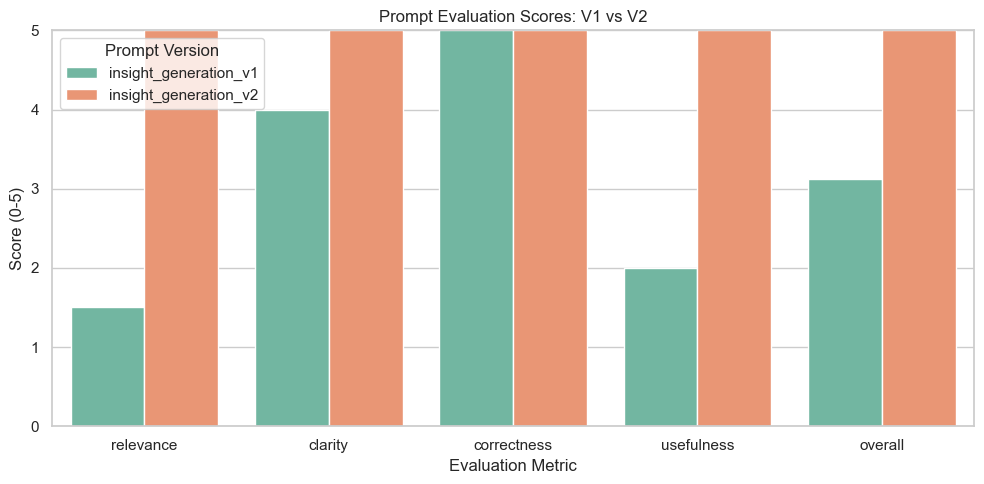

In [15]:

score_columns = ["relevance", "clarity", "correctness", "usefulness", "overall"]
plot_df = evaluation_df.melt(
    id_vars="prompt_version",
    value_vars=score_columns,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="prompt_version")
plt.ylim(0, 5)
plt.title("Prompt Evaluation Scores: V1 vs V2")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score (0-5)")
plt.legend(title="Prompt Version")
plt.tight_layout()
plt.show()


In [16]:

print("Prompt V1 structured output")
print(json.dumps(prompt_outputs["insight_generation_v1"]["structured_output"], indent=2))
print("\n" + "=" * 90 + "\n")
print("Prompt V2 structured output")
print(json.dumps(prompt_outputs["insight_generation_v2"]["structured_output"], indent=2))


Prompt V1 structured output
{
  "summary": "Retrieved reviews for 'What product issues should the business fix first?' show customer feedback around great, problem, issue, return, broken, disappointed.",
  "insights": [
    "Customers describe both positive usage moments and points of friction.",
    "Several retrieved comments include concrete product experience details."
  ],
  "recommendations": [
    "Investigate recurring complaints in the retrieved reviews.",
    "Use positive customer language in marketing copy."
  ]
}


Prompt V2 structured output
{
  "executive_summary": "The retrieved reviews for 'What product issues should the business fix first?' show a sentiment mix of {'positive': 25.0, 'neutral': 25.0, 'negative': 50.0}. Customers appear to value great, while recurring risk signals include problem, issue, return, broken, disappointed.",
  "sentiment_readout": {
    "positive": 25.0,
    "neutral": 25.0,
    "negative": 50.0
  },
  "top_insights": [
    {
      "insight":

## 10. Business Insights

This section aggregates outputs across several realistic business questions and converts them into a compact insight table. The goal is to show how the assistant can support product, marketing, and customer support workflows.


In [17]:

business_questions = [
    "What product issues should the business fix first?",
    "What do customers like most and how can marketing use it?",
    "Which customer complaints create the highest business risk?",
    "What should customer support proactively communicate to reduce dissatisfaction?",
]

insight_rows = []
for question in business_questions:
    result = run_insight_pipeline(question, prompt_version="insight_generation_v2", top_k=8)
    scores = evaluate_output(question, result["evidence"], result["structured_output"])
    output = result["structured_output"]
    insight_rows.append({
        "business_question": question,
        "used_llm": result["used_llm"],
        "overall_quality_score": scores["overall"],
        "executive_summary": output.get("executive_summary", output.get("summary", "")),
        "top_retrieved_sentiment": result["evidence"]["sentiment"].mode().iloc[0],
    })

business_insight_df = pd.DataFrame(insight_rows)
business_insight_df


,business_question,used_llm,overall_quality_score,executive_summary,top_retrieved_sentiment
0,What product issues should the business fix fi...,False,5.00,The retrieved reviews for 'What product issues...,negative
1,What do customers like most and how can market...,False,5.00,The retrieved reviews for 'What do customers l...,positive
2,Which customer complaints create the highest b...,False,5.00,The retrieved reviews for 'Which customer comp...,positive
3,What should customer support proactively commu...,False,4.75,The retrieved reviews for 'What should custome...,negative


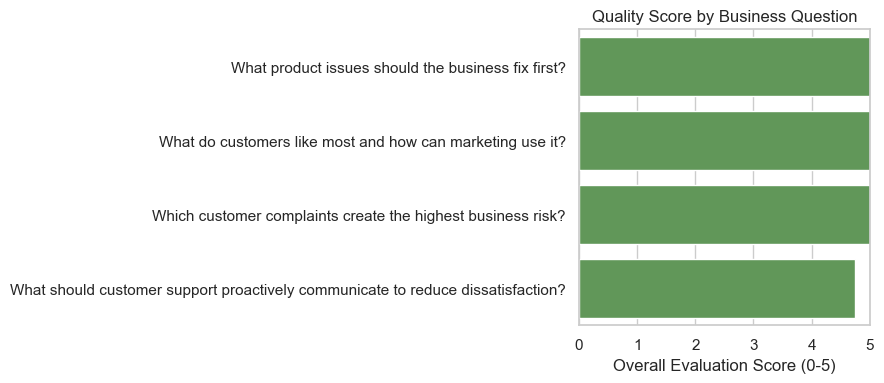

In [18]:

plt.figure(figsize=(9, 4))
sns.barplot(
    data=business_insight_df,
    y="business_question",
    x="overall_quality_score",
    color="#59A14F",
)
plt.xlim(0, 5)
plt.title("Quality Score by Business Question")
plt.xlabel("Overall Evaluation Score (0-5)")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [19]:

def print_business_report(row: pd.Series) -> None:
    print("Question:", row["business_question"])
    print("Quality score:", row["overall_quality_score"])
    print("Dominant retrieved sentiment:", row["top_retrieved_sentiment"])
    print("Summary:", textwrap.fill(str(row["executive_summary"]), width=100))
    print("-" * 100)

for _, row in business_insight_df.iterrows():
    print_business_report(row)


Question: What product issues should the business fix first?
Quality score: 5.0
Dominant retrieved sentiment: negative
Summary: The retrieved reviews for 'What product issues should the business fix first?' show a sentiment mix
of {'positive': 25.0, 'neutral': 25.0, 'negative': 50.0}. Customers appear to value great, while
recurring risk signals include problem, issue, return, broken, disappointed.
----------------------------------------------------------------------------------------------------
Question: What do customers like most and how can marketing use it?
Quality score: 5.0
Dominant retrieved sentiment: positive
Summary: The retrieved reviews for 'What do customers like most and how can marketing use it?' show a
sentiment mix of {'positive': 62.5, 'neutral': 0.0, 'negative': 37.5}. Customers appear to value
easy, great, while recurring risk signals include problem.
----------------------------------------------------------------------------------------------------
Question: Wh

## 11. Conclusion

This notebook demonstrates a production-style LLM application pattern for business insight generation:

- A public review dataset is loaded automatically.
- Customer text is cleaned, labeled, and converted into retrieval-ready chunks.
- A RAG-style retrieval step grounds the model in relevant customer evidence.
- Prompt templates cover summarization, sentiment analysis, insight generation, and recommendation generation.
- Structured JSON output supports downstream dashboards and evaluation.
- Two prompt versions are compared using relevance, clarity, correctness, and usefulness scores.
- Visualizations communicate sentiment distribution, keywords, prompt quality, and business insight quality.

Recommended production upgrades:

- Replace TF-IDF retrieval with sentence embeddings and a vector database.
- Use a stronger hosted or open-source instruction-tuned model.
- Add human-labeled evaluation examples for regression testing.
- Track prompt versions, retrieval evidence, and quality scores with experiment logging.
- Integrate the pipeline into a dashboard for product, marketing, and support teams.
